In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATASETS = 'C:\AliCode\Datasets'
ONLINE_DATASET = 'data_online'

ONLINE_DATASET_PATH = os.path.join(DATASETS, ONLINE_DATASET)

In [3]:
df_main = None

files = [1000, 1500, 2000, 2500, 3000, 3500, 5000, 6000]
# files = [6000]
for csv in os.listdir(ONLINE_DATASET_PATH):
    if csv.startswith('main') and int(csv.split('_')[1].split('.')[0]) in files:
        tmp = pd.read_csv(os.path.join(ONLINE_DATASET_PATH, csv))
        if df_main is None:
            df_main = tmp
        else:
            tmp['id'] += df_main['id'].max() +1
            df_main = pd.concat([df_main, tmp])
df_main.reset_index(inplace=True, drop=True)
df_main


,id,gender,age,csv,img,line,cms
0,0,f,19,Dataset/Data_1000/csv/csv_0000_0.csv,Dataset/Data_1000/img/img_0000_0.png,کے درمیان رہنے کا امکان ہے۔ رواں مالی سال 2010-11,NaN
1,0,f,19,Dataset/Data_1000/csv/csv_0000_1.csv,Dataset/Data_1000/img/img_0000_1.png,سب سے بڑا ہوں۔ (۶۴)ذکر سے جنت میں گھر تعمیر,NaN
2,0,f,19,Dataset/Data_1000/csv/csv_0000_2.csv,Dataset/Data_1000/img/img_0000_2.png,لاہور( پ ر)پاکستان مسلم لیگ (ن) اوورسیز کے مرکزی,NaN
3,0,f,19,Dataset/Data_1000/csv/csv_0000_3.csv,Dataset/Data_1000/img/img_0000_3.png,سیکرٹری آئما خطباء نے حکومت سے مطالبہ کیا کہ ش...,NaN
4,0,f,19,Dataset/Data_1000/csv/csv_0000_4.csv,Dataset/Data_1000/img/img_0000_4.png,لیں ، قبائلی رہنماوٴں نے سینیٹ میں شمالی وزیر ...,NaN
...,...,...,...,...,...,...,...
2398,314,f,27,Dataset/Data_6000/csv/csv_0042_3.csv,Dataset/Data_6000/img/img_0042_3.png,کرنے کے بار بار مواقع نہیں ملتے یہ بات یاد,58mphill
2399,314,f,27,Dataset/Data_6000/csv/csv_0042_4.csv,Dataset/Data_6000/img/img_0042_4.png,مراکز تعمیر ہوئے ہیں جن کے ساتھ کوئی خاطرخواہ,58mphill
2400,314,f,27,Dataset/Data_6000/csv/csv_0042_5.csv,Dataset/Data_6000/img/img_0042_5.png,اس دریچے کو کھلا رہنے دو,58mphill
2401,314,f,27,Dataset/Data_6000/csv/csv_0042_6.csv,Dataset/Data_6000/img/img_0042_6.png,پاکستان کا ہاتھ تھاما ہے'' جبکہ دوسرا ہاتھ چین...,58mphill


In [4]:
# pages = df_main["id"].value_counts()
# total_pages = len(pages)

# train = np.random.choice(pages.index, size=int(0.8*total_pages), replace=False)
# test = np.setdiff1d(pages.index, train)
# val = np.random.choice(test, size=int(0.5*len(test)), replace=False)
# test = np.setdiff1d(test, val)




In [5]:
df_tmp = df_main.copy()
df_tmp["bucket"] = df_tmp["csv"].apply(lambda x: int(x.split('/')[1].split('_')[1]))
main = df_tmp.groupby('id').agg({'bucket': 'first'}).reset_index()
main

,id,bucket
0,0,1000
1,1,1000
2,2,1000
3,3,1000
4,4,1000
...,...,...
306,310,6000
307,311,6000
308,312,6000
309,313,6000


In [6]:
# pages = df_main.groupby('bucket').agg({'id': set}).reset_index()
# pages = pages.explode('id').reset_index(drop=True)
# pages[""]

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(main, test_size=0.2, random_state=42, stratify=main['bucket'])
test, val = train_test_split(test, test_size=0.5, random_state=42, stratify=test['bucket'])

In [8]:
train["id"]

93      95
90      92
187    190
124    127
161    164
      ... 
199    202
137    140
181    184
56      57
16      16
Name: id, Length: 248, dtype: int64

In [9]:
val

,id,bucket
206,209,3000
38,38,1000
71,72,1500
14,14,1000
42,43,1000
88,90,2000
265,269,5000
269,273,6000
276,280,6000
163,166,2500


In [10]:
test

,id,bucket
55,56,1500
255,259,5000
111,114,2000
18,18,1000
101,103,2000
205,208,3000
283,287,6000
223,227,5000
135,138,2500
299,303,6000


In [11]:
test_csv = df_main[df_main['id'].isin(test["id"])]
train_csv = df_main[df_main['id'].isin(train["id"])]
val_csv = df_main[df_main['id'].isin(val["id"])]

# test_csv = test.drop(columns=['bucket'])
# train_csv = train.drop(columns=['bucket'])
# val_csv = val.drop(columns=['bucket'])

# test_csv.to_csv(os.path.join(ONLINE_DATASET_PATH, 'test_leakproof_raw2.csv'), index=False)
# train_csv.to_csv(os.path.join(ONLINE_DATASET_PATH, 'train_leakproof_raw2.csv'), index=False)
# val_csv.to_csv(os.path.join(ONLINE_DATASET_PATH, 'val_leakproof_raw2.csv'), index=False)

In [12]:
test_csv

,id,gender,age,csv,img,line,cms
55,7,m,19,Dataset/Data_1000/csv/csv_0007_0.csv,Dataset/Data_1000/img/img_0007_0.png,اور لوگوں کی حالت ایسے کے ویسے ہے۔ پاکستان,NaN
56,7,m,19,Dataset/Data_1000/csv/csv_0007_1.csv,Dataset/Data_1000/img/img_0007_1.png,اور وہ اس نعمت کو دوسرے کے لئے پسند نہیں,NaN
57,7,m,19,Dataset/Data_1000/csv/csv_0007_2.csv,Dataset/Data_1000/img/img_0007_2.png,سخت نوٹس لیا اور متعلقہ افسران کی سرزنش کر کے,NaN
58,7,m,19,Dataset/Data_1000/csv/csv_0007_3.csv,Dataset/Data_1000/img/img_0007_3.png,دلایا۔ 35 فی صد نے کہا کہ وہ اپنے دوستوں,NaN
59,7,m,19,Dataset/Data_1000/csv/csv_0007_4.csv,Dataset/Data_1000/img/img_0007_4.png,وزیراعظم ہائوس تک گیا اور وہاں کے نمائندوں نے ...,NaN
...,...,...,...,...,...,...,...
2350,308,f,22,Dataset/Data_6000/csv/csv_0036_3.csv,Dataset/Data_6000/img/img_0036_3.png,جرجیر کی وجہ سے تسمیہ کے بارے میں حکایت,19m5
2351,308,f,22,Dataset/Data_6000/csv/csv_0036_4.csv,Dataset/Data_6000/img/img_0036_4.png,تھی اس سے دولت کی لالچ اور سفاک طاقت کی,19m5
2352,308,f,22,Dataset/Data_6000/csv/csv_0036_5.csv,Dataset/Data_6000/img/img_0036_5.png,یہ دانشور کہسیانی بلی بن جاتے ہیں۔ پاکستان کے ...,19m5
2353,308,f,22,Dataset/Data_6000/csv/csv_0036_6.csv,Dataset/Data_6000/img/img_0036_6.png,کہ 370ہزار بچے سائیکو سوشل فرسٹ ایڈ لینے پر مجبور,19m5


In [13]:
# for id in test_csv["id"]:
#     for id2 in train_csv["id"]:
#             for id3 in val_csv["id"]:
#                     if id == id2 or id == id3 or id2 == id3:
#                         print("Leakage detected!")

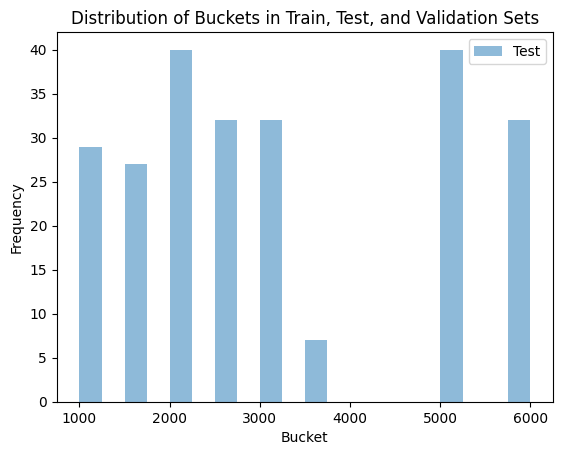

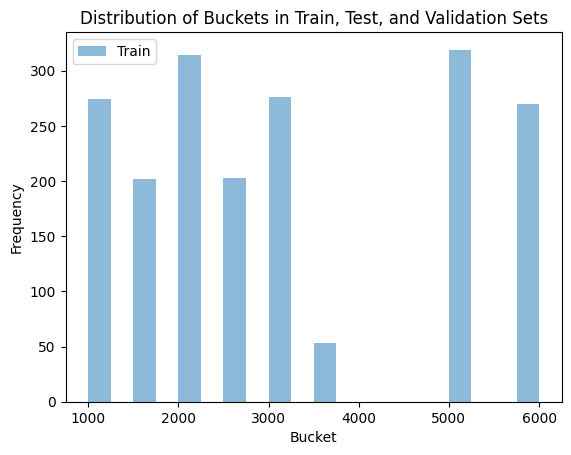

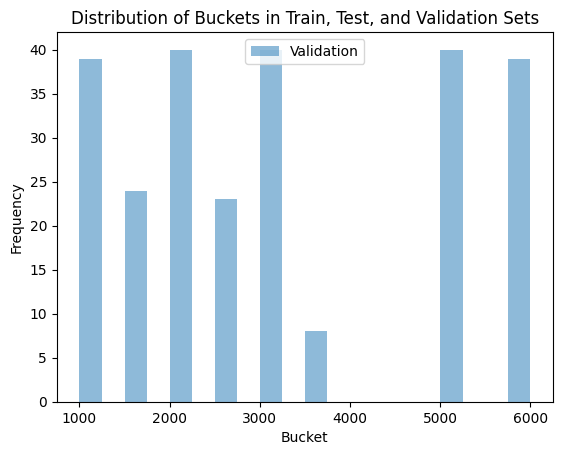

In [14]:
plt.hist(df_tmp[df_tmp['id'].isin(test["id"])]['bucket'], bins=20, alpha=0.5, label='Test')
plt.xlabel('Bucket')
plt.ylabel('Frequency')
plt.title('Distribution of Buckets in Train, Test, and Validation Sets')
plt.legend()
plt.show()
plt.clf()
plt.hist(df_tmp[df_tmp['id'].isin(train["id"])]['bucket'], bins=20, alpha=0.5, label='Train')
plt.xlabel('Bucket')
plt.ylabel('Frequency')
plt.title('Distribution of Buckets in Train, Test, and Validation Sets')
plt.legend()
plt.show()
plt.clf()
plt.hist(df_tmp[df_tmp['id'].isin(val["id"])]['bucket'], bins=20, alpha=0.5, label='Validation')
plt.xlabel('Bucket')
plt.ylabel('Frequency')
plt.title('Distribution of Buckets in Train, Test, and Validation Sets')
plt.legend()
plt.show()

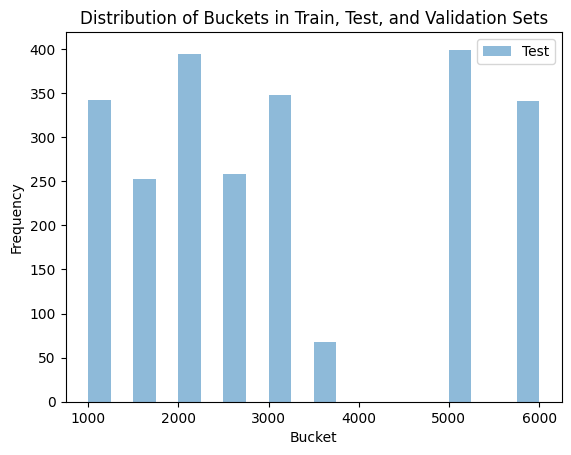

In [15]:
plt.hist(df_tmp['bucket'], bins=20, alpha=0.5, label='Test')
plt.xlabel('Bucket')
plt.ylabel('Frequency')
plt.title('Distribution of Buckets in Train, Test, and Validation Sets')
plt.legend()
plt.show()

In [16]:
df_tmp['bucket'].groupby(df_tmp['id']).first().value_counts()

bucket
2000    50
5000    50
1000    47
3000    45
6000    43
1500    34
2500    33
3500     9
Name: count, dtype: int64

In [20]:
weights = {
    "1000": 0.5,
    "2000": 0.5,
    "3000": 0.5,
    "5000": 1,
    "1500": 1,
    "2500": 1,
    "6000": 1,
    "3500": 1
    
}
# writers = 0
# for bucket, weight in weights.items():
#     writers += df_tmp[df_tmp['bucket'] == int(bucket)]['id'].nunique() * weight

writers = df_tmp['bucket'].groupby(df_tmp['id']).first().apply(lambda x: weights[str(x)]).sum()
print(f"Total writers (weighted): {writers}")

Total writers (weighted): 240.0


In [19]:
writers

240.0

In [4]:
import pandas as pd
import re
import unicodedata

def normalize_urdu(text):
    # Unicode normalization
    text = unicodedata.normalize("NFC", str(text))
    
    # Remove tatweel
    text = text.replace("ـ", "")
    
    # Remove ZWNJ
    text = text.replace("\u200c", "")
    
    # Remove punctuation (keep Urdu letters and spaces)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


unique_ligatures = set()

for line in df_main["line"]:
    clean_line = normalize_urdu(line)
    ligatures = clean_line.split(" ")
    unique_ligatures.update(ligatures)

print("Total Unique Ligatures:", len(unique_ligatures))

Total Unique Ligatures: 5829


In [5]:
import pandas as pd
import re
import unicodedata

def normalize_urdu(text):
    # Unicode normalization
    text = unicodedata.normalize("NFC", str(text))
    
    # Remove tatweel
    text = text.replace("ـ", "")
    
    # Remove ZWNJ
    text = text.replace("\u200c", "")
    
    # Remove punctuation (keep Urdu letters and spaces)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


total_chars = 0
total_words = 0
for line in df_main["line"]:
    clean_line = normalize_urdu(line)
    words = clean_line.split(" ")
    total_words += len(words)
    chars = len(clean_line.replace(" ", ""))
    total_chars += chars

print("Total Characters:", total_chars)
print("Average Characters per Line:", total_chars / len(df_main["line"]))
print("Total Words:", total_words)
print("Average Words per Line:", total_words / len(df_main["line"]))

Total Characters: 83946
Average Characters per Line: 34.93383270911361
Total Words: 23209
Average Words per Line: 9.658343736995423


In [6]:
import os
import shutil

save_folder = "C:\\AliCode\\Datasets\\test_outputs"

for dirs in os.listdir("C:\\AliCode\\Datasets\\data_online_line_width_alpha\\Dataset\\Data_1000"):
    if dirs.startswith('.'):
        continue
    img_paths = os.listdir(os.path.join("C:\\AliCode\\Datasets\\data_online_line_width_alpha\\Dataset\\Data_1000", dirs))
    img_path = img_paths[1]
    print(f"Directory: {dirs}, Sample Image: {img_path}")
    shutil.copy(os.path.join("C:\\AliCode\\Datasets\\data_online_line_width_alpha\\Dataset\\Data_1000", dirs, img_path), os.path.join(save_folder, f"{dirs}_{img_path}"))
    
    

Directory: csv, Sample Image: csv_0000_1.csv
Directory: img, Sample Image: img_0000_1.png
Directory: img_acceleration, Sample Image: img_0000_1.png
Directory: img_cos_theta, Sample Image: img_0000_1.png
Directory: img_curvature, Sample Image: img_0000_1.png
Directory: img_dt, Sample Image: img_0000_1.png
Directory: img_dtheta, Sample Image: img_0000_1.png
Directory: img_dvx, Sample Image: img_0000_1.png
Directory: img_dvy, Sample Image: img_0000_1.png
Directory: img_dx, Sample Image: img_0000_1.png
Directory: img_dy, Sample Image: img_0000_1.png
Directory: img_Pressure, Sample Image: img_0000_1.png
Directory: img_sin_theta, Sample Image: img_0000_1.png
Directory: img_speed, Sample Image: img_0000_1.png
Directory: img_Stroke, Sample Image: img_0000_1.png
Directory: img_stroke_duration, Sample Image: img_0000_1.png
Directory: img_stroke_id, Sample Image: img_0000_1.png
Directory: img_stroke_time, Sample Image: img_0000_1.png
Directory: img_stroke_time_norm, Sample Image: img_0000_1.png
D